# L4b Advanced: Monte Carlo Versus the Closed Form

How accurately can simulation estimate the probability that a trade exceeds a target discounted return?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate a target probability:** Calculate the fraction of simulated trades that exceed the target and use its standard error to describe sampling uncertainty.
> * **Compare simulation methods:** Compare the exact GBM transition with the Euler–Maruyama time-stepping approximation and examine how the time step affects the results.
> * **Reduce sampling uncertainty:** Pair simulations using opposite random shocks and compare their precision with independent simulations using the same number of paths.

In this example, we compare Monte Carlo probability estimates with the lecture’s closed-form result. We examine how the path count affects precision, study the error from approximate time steps, and use opposite-shock pairs—called *antithetic variates*—to reduce sampling uncertainty.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/), [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/), [Distributions.jl documentation](https://juliastats.org/Distributions.jl/stable/), [Plots.jl documentation](https://docs.juliaplots.org/stable/), and [PrettyTables.jl documentation](https://ronisbr.github.io/PrettyTables.jl/stable/) for the functions and types used here.

Let's set the plotting defaults:


In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

__Constants.__ Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units:


In [3]:
S₀ = 100.0;    # initial share price (USD/share)
μ = 0.15;      # arithmetic GBM drift (1/year)
σ = 0.30;      # GBM volatility (1/√year)
T = 63/252;    # holding period (years)
N = 63;        # number of time steps over the holding period
g_y = 0.05;    # continuously compounded annual benchmark growth rate (1/year)
ρ_star = 0.10; # target scaled NPV (dimensionless; must exceed -1)
μ_g = μ - σ^2/2; # mean growth rate (1/year)

path_counts = (100, 1_000, 10_000, 100_000, 1_000_000); # path counts to compare

comparison_horizon = 1.0;          # holding period for the method comparison (years)
comparison_steps = (1, 2, 4, 12, 52, 252); # time-step counts to compare
comparison_paths = 200_000;        # simulated paths per method and step count

antithetic_pairs = 50_000; # independent pairs; each pair contains two simulated paths


___

## Task 1: Estimate the Target Probability and Its Standard Error

In this task, we estimate the probability of exceeding a target discounted return using independent simulated paths. We compare the estimate with the lecture’s closed-form result and use its standard error to describe sampling uncertainty.

For a long position held until $T$, the scaled NPV is given by:

$$
\rho_T=e^{-g_yT}\frac{S_T}{S_0}-1.
$$

Exceeding the target $\rho_\star$ therefore requires:

$$
\ln\frac{S_T}{S_0}>\ln(1+\rho_\star)+g_yT.
$$

Under GBM, the log-price change is normally distributed with mean $\mu_gT$ and standard deviation $\sigma\sqrt{T}$. Thus, the target probability is given by:

$$
p=\mathbb P(\rho_T>\rho_\star)
=1-\Phi\!\left(
\frac{\ln(1+\rho_\star)+g_yT-\mu_gT}{\sigma\sqrt{T}}
\right),
$$

where $\Phi$ is the standard normal cumulative distribution function. Let's compute this probability using the constants above.


In [4]:
target_probability(μ_g::Real, σ::Real, T::Real, g_y::Real, ρ_star::Real) =
    ccdf(Normal(), (log1p(ρ_star) + g_y*T - μ_g*T)/(σ*sqrt(T)))

p_exact = target_probability(μ_g, σ, T, g_y, ρ_star)
println("Closed form: P(ρ_T > $(ρ_star)) = $(round(p_exact, digits = 6))")

Closed form: P(ρ_T > 0.1) = 0.293312


We simulate $M$ independent price paths using the lecture’s exact GBM transition. For each path, we calculate the scaled NPV at the holding period’s end and check whether it exceeds $\rho_\star$.

Each successful trade contributes 1; each unsuccessful trade contributes 0. The estimated probability is therefore the fraction of simulated trades that exceed the target:

$$
\hat p=\frac{\text{number of trades exceeding the target}}{M}.
$$

Generating another set of $M$ paths may change the fraction exceeding the target, even with fixed model parameters. The standard error describes how much this estimate typically varies across repeated simulations.

The probability estimate $\hat p$ is the sample mean of the 0-or-1 trade outcomes. We quantify its sampling uncertainty using the standard error of that mean. This helps us judge whether a difference from the closed-form probability is consistent with random sampling and whether greater precision requires more paths.

Each outcome has variance $p(1-p)$, where $p$ is the model's target probability. Averaging $M$ independent outcomes gives the standard error:

$$
\mathrm{SE}(\hat p)=\frac{\sqrt{p(1-p)}}{\sqrt M}.
$$

This describes how the estimated mean varies across repeated simulations; it does not give the actual difference $\hat p-p$ for a particular run. We estimate this standard error by replacing $p$ with the observed success fraction $\hat p$:

$$
\widehat{\mathrm{SE}}(\hat p)=\sqrt{\frac{\hat p(1-\hat p)}{M}}.
$$

Let's write the simulator. For each path, we apply $N$ exact GBM steps, calculate the final scaled NPV, and count whether it exceeds the target. The simulator returns the estimated probability, its estimated standard error, and the number of simulated paths.


In [5]:
function simulate_target_probability(S₀::Real, μ::Real, σ::Real, T::Real, N::Int, g_y::Real, ρ_star::Real;
        number_of_paths::Int = 100_000, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    drift = (μ - 0.5*σ^2)*Δt
    shock = σ*sqrt(Δt)
    discount = exp(-g_y*T)
    hits = 0
    for _ ∈ 1:number_of_paths
        S = S₀
        for _ ∈ 1:N
            S *= exp(drift + shock*randn(rng))   # exact one-step GBM transition
        end
        ρ_T = (S/S₀)*discount - 1               # scaled NPV of the scheduled trade
        hits += (ρ_T > ρ_star)
    end
    p_hat = hits/number_of_paths
    return (probability = p_hat, standard_error = sqrt(p_hat*(1 - p_hat)/number_of_paths), number_of_paths = number_of_paths)
end

simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = 100_000)

(probability = 0.29404, standard_error = 0.0014407653466126952, number_of_paths = 100000)

Let's run the simulator for each path count in `path_counts` and store the results in `convergence_table::DataFrame`. We report the estimated probability, its standard error, and its difference from the closed-form probability. The `error_in_se` column measures how many estimated standard errors separate the simulated and closed-form probabilities.


In [6]:
convergence_table = let
    df = DataFrame(M = Int[], estimate = Float64[], standard_error = Float64[], error = Float64[], error_in_se = Float64[])
    for M ∈ path_counts
        r = simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = M)
        push!(df, (M, r.probability, r.standard_error, r.probability - p_exact, (r.probability - p_exact)/r.standard_error))
    end
    df
end
pretty_table(convergence_table;
    table_format = TextTableFormat(borders = text_table_borders__simple),
    formatters = [fmt__printf("%.5f", [2,3,4]), fmt__printf("%.2f", [5])])

========== ========== ================ ========== ==============
        M   estimate   standard_error      error   error_in_se 
    Int64    Float64          Float64    Float64       Float64 
========== ========== ================ ========== ==============
      100    0.33000          0.04702    0.03669          0.78
     1000    0.28900          0.01433   -0.00431         -0.30
    10000    0.28810          0.00453   -0.00521         -1.15
   100000    0.29404          0.00144    0.00073          0.51
  1000000    0.29292          0.00046   -0.00039         -0.85
========== ========== ================ ========== ==============


As the number of paths grows, the standard error decreases approximately as $1/\sqrt{M}$. Reducing it tenfold therefore requires about one hundred times as many paths.

Let's compare the simulated estimates with the closed-form probability. The error bars extend $1.96$ estimated standard errors above and below each estimate, giving approximate 95% confidence intervals.


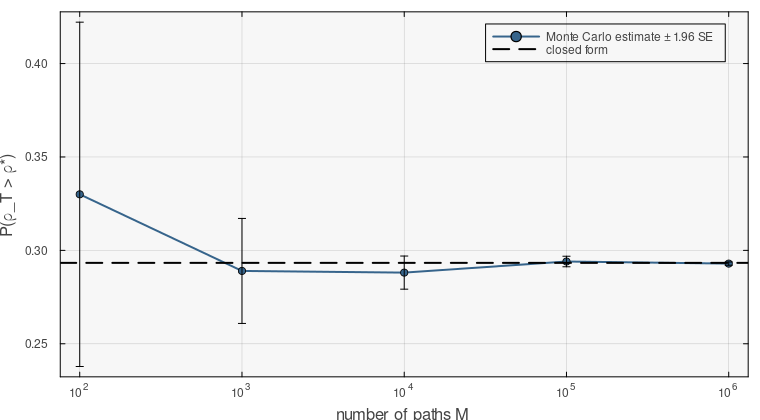

In [7]:
let
    M = convergence_table.M
    est = convergence_table.estimate
    se = convergence_table.standard_error
    plot(M, est; xscale = :log10, yerror = 1.96 .* se, marker = :circle, color = :steelblue4,
        label = "Monte Carlo estimate ± 1.96 SE", xlabel = "number of paths M", ylabel = "P(ρ_T > ρ*)",
        size = (760, 420), legend = :topright)
    hline!([p_exact]; color = :black, linestyle = :dash, label = "closed form")
end

___

## Task 2: Compare Exact and Euler–Maruyama Simulation

In this task, we compare Euler–Maruyama with the exact GBM transition to examine how the time step affects terminal prices and the estimated target probability.

Euler–Maruyama approximates the price change over a short interval using its starting price:

$$
\Delta S_j\approx
\mu S_{t_{j-1}}\Delta t
+\sigma S_{t_{j-1}}\sqrt{\Delta t}\,Z_j,
$$

where the $Z_j$ are independent standard normal draws. Adding this change to the starting price gives the update:

$$
S_{t_j}
=S_{t_{j-1}}
\left(1+\mu\Delta t+\sigma\sqrt{\Delta t}\,Z_j\right).
$$

For $N$ steps of length $\Delta t=T/N$, the expected terminal price is given by:

$$
\mathbb E[S_T^{\mathrm{EM}}]
=S_0(1+\mu\Delta t)^N.
$$

As the time step decreases, this approaches the exact GBM mean, $S_0e^{\mu T}$. Coarse steps can also produce nonpositive prices, which are impossible under GBM.

More simulated paths improve the probability estimate’s precision, but finite-step approximation error can remain. Let’s examine this error by decreasing the time step while keeping the holding period fixed.

We use `comparison_horizon` years, the step counts in `comparison_steps`, and `comparison_paths` paths per method. The GBM parameters, benchmark rate, and target remain fixed.


In [8]:
function simulate_terminal(S₀::Real, μ::Real, σ::Real, T::Real, N::Int; scheme::Symbol = :exact,
        number_of_paths::Int, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    S_T = zeros(Float64, number_of_paths)
    negatives = 0
    for m ∈ 1:number_of_paths
        S = S₀
        for _ ∈ 1:N
            Z = randn(rng)
            if scheme == :exact
                S *= exp((μ - 0.5*σ^2)*Δt + σ*sqrt(Δt)*Z)   # exact transition
            else
                S *= 1 + μ*Δt + σ*sqrt(Δt)*Z                # Euler–Maruyama step
            end
        end
        negatives += (S <= 0)
        S_T[m] = S
    end
    return (S_T = S_T, negatives = negatives)
end

comparison_probability = target_probability(μ_g, σ, comparison_horizon, g_y, ρ_star)
comparison_standard_error = sqrt(comparison_probability*(1-comparison_probability)/comparison_paths)

euler_table = let
    df = DataFrame(N = Int[], Δt = Float64[], exact = Float64[], euler = Float64[], probability_error = Float64[],
        euler_mean = Float64[], neg = Int[])
    for comparison_N ∈ comparison_steps
        ex = simulate_terminal(S₀, μ, σ, comparison_horizon, comparison_N; scheme = :exact, number_of_paths = comparison_paths)
        eu = simulate_terminal(S₀, μ, σ, comparison_horizon, comparison_N; scheme = :euler, number_of_paths = comparison_paths)
        discount = exp(-g_y*comparison_horizon)
        p_ex = mean((ex.S_T ./ S₀) .* discount .- 1 .> ρ_star)
        p_eu = mean((eu.S_T ./ S₀) .* discount .- 1 .> ρ_star)
        push!(df, (comparison_N, comparison_horizon/comparison_N, p_ex, p_eu, p_eu - comparison_probability, S₀*(1 + μ*comparison_horizon/comparison_N)^comparison_N, eu.negatives))
    end
    println("Closed form over $(comparison_horizon) years: P(ρ_T > $(ρ_star)) = $(round(comparison_probability, digits = 4)); Monte Carlo standard error ≈ $(round(comparison_standard_error, digits = 4))")
    println("Exact terminal mean S₀ exp(μT) = $(round(S₀*exp(μ*comparison_horizon), digits = 2)) USD/share; the Euler–Maruyama mean is S₀(1 + μΔt)^N")
    df
end
pretty_table(euler_table;
    table_format = TextTableFormat(borders = text_table_borders__simple),
    formatters = [fmt__printf("%.4f", [2,3,4,5]), fmt__printf("%.2f", [6])])

Closed form over 1.0 years: P(ρ_T > 0.1) = 0.4466; Monte Carlo standard error ≈ 0.0011
Exact terminal mean S₀ exp(μT) = 116.18 USD/share; the Euler–Maruyama mean is S₀(1 + μΔt)^N
======== ========= ========= ========= =================== ============ ========
      N        Δt     exact     euler   probability_error   euler_mean     neg 
  Int64   Float64   Float64   Float64             Float64      Float64   Int64 
======== ========= ========= ========= =================== ============ ========
      1    1.0000    0.4454    0.4904              0.0438       115.00       9
      2    0.5000    0.4454    0.4710              0.0245       115.56       1
      4    0.2500    0.4461    0.4592              0.0127       115.87       0
     12    0.0833    0.4457    0.4499              0.0033       116.08       0
     52    0.0192    0.4474    0.4484              0.0018       116.16       0
    252    0.0040    0.4452    0.4457             -0.0008       116.18       0
======== ========= ======

The `exact` and `euler` columns report simulated target probabilities. The `euler_mean` column gives the expected terminal price computed using Euler–Maruyama discretization, while `neg` counts nonpositive terminal prices produced by that method.

The `probability_error` column is the Euler–Maruyama probability estimate minus the closed-form probability. This difference reflects time-step approximation error and random sampling variation.

Let’s plot the magnitude of this difference against the time step and compare it with the Monte Carlo standard error.


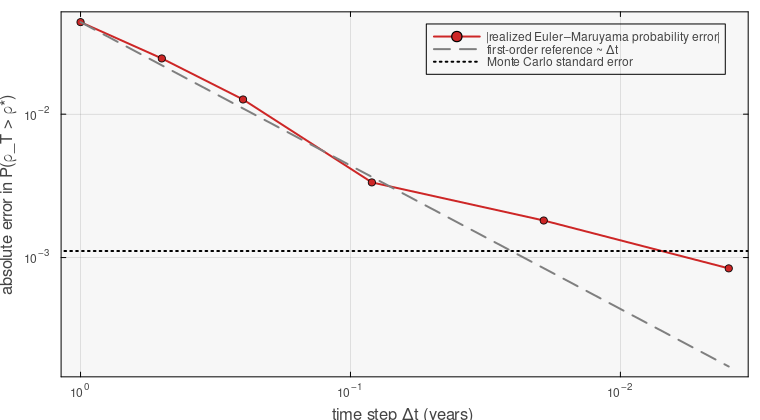

In [9]:
let
    keep = euler_table.probability_error .!= 0
    plot(euler_table.Δt[keep], abs.(euler_table.probability_error[keep]);
        xscale=:log10, yscale=:log10, marker=:circle, color=:firebrick3,
        label="|realized Euler–Maruyama probability error|", xlabel="time step Δt (years)",
        ylabel="absolute error in P(ρ_T > ρ*)", size=(760, 420), legend=:topright, xflip=true)
    e1 = abs(euler_table.probability_error[1])
    plot!(euler_table.Δt[keep], e1 .* (euler_table.Δt[keep] ./ euler_table.Δt[1]);
        color=:gray50, linestyle=:dash, label="first-order reference ~ Δt")
    hline!([comparison_standard_error]; color=:black, linestyle=:dot,
        label="Monte Carlo standard error")
end

The dashed line shows the reference trend: halving the time step halves the error. The horizontal line shows the typical variation in a probability estimate from random sampling. When the plotted error is near this line, we cannot tell from one simulation how much comes from the Euler–Maruyama approximation and how much comes from random sampling.

Finer Euler–Maruyama steps require more work per path. For GBM, we avoid this approximation error by using the exact transition.

___

## Task 3: Reduce Sampling Error with Antithetic Pairs

In this task, we use **antithetic variates**—pairs of paths with opposite random shocks—to reduce sampling uncertainty.

We simulate one path using $(Z_1,\ldots,Z_N)$ and another using $(-Z_1,\ldots,-Z_N)$. Shocks that raise one path’s terminal price lower the other’s, making their target-success outcomes negatively correlated. Averaging these outcomes reduces variance compared with two independent paths.

Each pair contributes 0, 0.5, or 1 when neither, one, or both paths exceed the target. We estimate the target probability by averaging these values. Because the pairs are independent, the estimated standard error is their sample standard deviation divided by the square root of the number of pairs.

Let’s compare `antithetic_pairs` pairs with the same total number of independent paths and report their probability estimates and standard errors.


In [10]:
function simulate_target_probability_antithetic(S₀::Real, μ::Real, σ::Real, T::Real, N::Int, g_y::Real, ρ_star::Real;
        number_of_pairs::Int, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    drift = (μ - 0.5*σ^2)*Δt
    shock = σ*sqrt(Δt)
    discount = exp(-g_y*T)
    pair_average = zeros(Float64, number_of_pairs)
    for m ∈ 1:number_of_pairs
        S_plus = S₀; S_minus = S₀
        for _ ∈ 1:N
            Z = randn(rng)
            S_plus *= exp(drift + shock*Z)      # the path
            S_minus *= exp(drift - shock*Z)     # its mirror image
        end
        hit_plus = ((S_plus/S₀)*discount - 1 > ρ_star)
        hit_minus = ((S_minus/S₀)*discount - 1 > ρ_star)
        pair_average[m] = 0.5*(hit_plus + hit_minus)
    end
    p_hat = mean(pair_average)
    return (probability = p_hat, standard_error = std(pair_average)/sqrt(number_of_pairs), number_of_paths = 2*number_of_pairs)
end

variance_reduction_table = let
    df = DataFrame(method = String[], paths = Int[], estimate = Float64[], standard_error = Float64[])
    plain = simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = 2*antithetic_pairs)
    anti = simulate_target_probability_antithetic(S₀, μ, σ, T, N, g_y, ρ_star; number_of_pairs = antithetic_pairs)
    push!(df, ("independent paths", plain.number_of_paths, plain.probability, plain.standard_error))
    push!(df, ("antithetic pairs", anti.number_of_paths, anti.probability, anti.standard_error))
    push!(df, ("closed form", 0, p_exact, 0.0))
    df
end
pretty_table(variance_reduction_table;
    table_format = TextTableFormat(borders = text_table_borders__simple),
    formatters = [fmt__printf("%.5f", [3,4])])

==================== ======== ========== =================
             method    paths   estimate   standard_error 
             String    Int64    Float64          Float64 
==================== ======== ========== =================
  independent paths   100000    0.29404          0.00144
   antithetic pairs   100000    0.29209          0.00110
        closed form        0    0.29331          0.00000
==================== ======== ========== =================


Compare the two methods’ `standard_error` values. A smaller standard error means the probability estimate varies less across repeated simulations using the same number of paths.

The benefit of antithetic pairing depends on the target probability. Near one half, pairs usually contain one successful and one unsuccessful trade, keeping their averages close to 0.5. The relative improvement shrinks as the target probability approaches zero or one.

Both methods estimate the same GBM target probability; pairing changes the sampling procedure and its precision.

___


## Summary

In this example, we estimated a target probability by simulation, compared exact and Euler–Maruyama transitions, and examined how antithetic pairing improves precision.

> **Key Takeaways:**
>
> - **Probability estimation:** We averaged successful and unsuccessful trade outcomes to estimate the target probability. Its standard error helped us assess sampling uncertainty and explain why greater precision requires more paths.
> - **Time-step approximation:** We compared Euler–Maruyama with the exact GBM transition to examine approximation error. We saw how sampling uncertainty can obscure the effect of reducing the time step.
> - **Antithetic pairing:** We paired paths using opposite shocks to reduce sampling uncertainty with the same total number of paths. We calculated the standard error from the independent pair averages.

These comparisons help us improve a simulation by adding paths, refining the time step, or changing how we sample.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
